# Classification framing that is closer to business


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v3'
RUN_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [2]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV,
    cross_val_predict, train_test_split,
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score,
    recall_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.base import BaseEstimator, ClassifierMixin

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


In [3]:
real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

LEAKAGE = ['budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
           'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_mov = real_mov.drop(columns=LEAKAGE, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE, errors='ignore')

META_KEEP = ['movie_id', 'targeted_emotion', 'clip_duration_s',
             'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
             'silence_ratio', 'music_presence', 'dialogue_density',
             'face_screen_time_ratio', 'lead_screen_time_ratio',
             'release_year', 'genre_primary', 'genre_secondary',
             'country_of_origin', 'budget_categorical',
             'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]
real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left'); real_mov['is_synthetic']=0
syn_mov  = syn_mov.merge(syn_meta_sub, on='movie_id', how='left');  syn_mov['is_synthetic']=1
df_all = pd.concat([real_mov, syn_mov], ignore_index=True)

DROP = {'movie_id','condition','n_participants',
        'imdb_rating','wom_multiplier','wom_multiplier_log','is_synthetic'}
df_feat = df_all.copy()
ORD = {'low':1,'moderate':2,'high':3}
for c in ['cut_count','brightness','motion_intensity','audio_loudness',
          'silence_ratio','music_presence','dialogue_density',
          'face_screen_time_ratio','lead_screen_time_ratio','budget_categorical']:
    if c in df_feat.columns: df_feat[c] = df_feat[c].map(ORD)
OH = [c for c in ['targeted_emotion','genre_primary','genre_secondary','country_of_origin']
      if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH, prefix_sep='_', dummy_na=False, dtype=int)

feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
X_all = X_all.drop(columns=X_all.columns[X_all.isna().all()].tolist())
X_all = X_all.drop(columns=X_all.columns[X_all.std()==0].tolist())
feature_cols = list(X_all.columns)

y_imdb = df_feat['imdb_rating'].astype(float)
y_wom  = df_feat['wom_multiplier_log'].astype(float)
synth_mask = df_feat['is_synthetic'].values.astype(bool)
print(f'Feature matrix: {X_all.shape}')

Feature matrix: (50, 360)


# Definition of business success tiers

Three-tier business classification:
average    25
flop       15
hit        10
Name: count, dtype: int64

Thresholds:
  Hit  (top 20%):  composite ≥ 0.681
  Flop (bot 30%):  composite ≤ -0.604

Class distributions per binary task:
  is_hit:  {0: 40, 1: 10}  (positive = 20%)
  is_flop: {0: 35, 1: 15}  (positive = 30%)


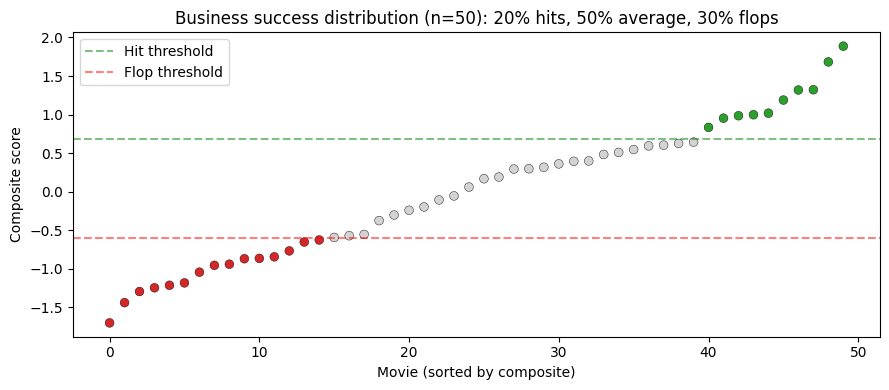

In [4]:
# Composite score
z_imdb = (y_imdb - y_imdb.mean()) / y_imdb.std()
z_wom  = (y_wom  - y_wom.mean())  / y_wom.std()
composite = (z_imdb + z_wom) / 2

# Three-tier categorisation
hit_threshold  = composite.quantile(0.80)   # top 20%
flop_threshold = composite.quantile(0.30)   # bottom 30%

is_hit  = (composite >= hit_threshold).astype(int)
is_flop = (composite <= flop_threshold).astype(int)

tier = pd.Series(['average'] * len(composite), index=composite.index)
tier[composite >= hit_threshold]  = 'hit'
tier[composite <= flop_threshold] = 'flop'

print('Three-tier business classification:')
print(tier.value_counts())
print(f'\nThresholds:')
print(f'  Hit  (top 20%):  composite ≥ {hit_threshold:.3f}')
print(f'  Flop (bot 30%):  composite ≤ {flop_threshold:.3f}')
print(f'\nClass distributions per binary task:')
print(f'  is_hit:  {is_hit.value_counts().to_dict()}  '
      f'(positive = {is_hit.mean():.0%})')
print(f'  is_flop: {is_flop.value_counts().to_dict()}  '
      f'(positive = {is_flop.mean():.0%})')

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if t == 'flop' else '#2ca02c' if t == 'hit' else 'lightgray'
          for t in tier]
ax.scatter(range(len(composite)), composite.sort_values().values,
           c=[colors[i] for i in composite.sort_values().index],
           s=40, edgecolor='k', linewidth=0.3)
ax.axhline(hit_threshold, color='green', linestyle='--', alpha=0.5, label='Hit threshold')
ax.axhline(flop_threshold, color='red', linestyle='--', alpha=0.5, label='Flop threshold')
ax.set_xlabel('Movie (sorted by composite)')
ax.set_ylabel('Composite score')
ax.set_title('Business success distribution (n=50): 20% hits, 50% average, 30% flops')
ax.legend()
plt.tight_layout(); plt.show()

# Classifier helper

In [5]:
class PLSDA(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.pls = PLSRegression(n_components=self.n_components, scale=False)
        self.pls.fit(X, y.astype(float))
        return self
    def predict_proba(self, X):
        s = np.clip(self.pls.predict(X).flatten(), 0, 1)
        return np.column_stack([1-s, s])
    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)

def make_enet(C=0.05, l1_ratio=0.3):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   LogisticRegression(penalty='elasticnet', solver='saga',
                                   C=C, l1_ratio=l1_ratio, class_weight='balanced',
                                   max_iter=10000, random_state=42))])
def make_l2(C=0.1):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   LogisticRegression(penalty='l2', C=C, class_weight='balanced',
                                   max_iter=10000, random_state=42))])
def make_rf():
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('m',   RandomForestClassifier(n_estimators=500, max_depth=5,
                                        max_features=0.3, class_weight='balanced',
                                        random_state=42, n_jobs=-1))])
def make_gbm():
    return Pipeline([
        ('m', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                                              max_depth=3, l2_regularization=1.0,
                                              class_weight='balanced',
                                              random_state=42))])
def make_plsda(n_components=2):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   PLSDA(n_components=n_components))])
def make_gpc():
    kernel = ConstantKernel(1.0) * RBF(length_scale=1.0, length_scale_bounds=(1e-2,1e3))
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   GaussianProcessClassifier(kernel=kernel, n_restarts_optimizer=10,
                                           random_state=42))])

CLASSIFIERS = {
    'LogReg-ElasticNet': make_enet,
    'LogReg-L2':         make_l2,
    'Random Forest':     make_rf,
    'Gradient Boosting': make_gbm,
    'PLS-DA':            make_plsda,
    'GP Classifier':     make_gpc,
}

# Helper for binary classification 

In [6]:
def get_proba(pipe, X):
    try:    return pipe.predict_proba(X)[:, 1]
    except Exception:
        try: return pipe.decision_function(X)
        except: return pipe.predict(X).astype(float)

def evaluate_binary(pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred  = pipe.predict(X_te)
    y_proba = get_proba(pipe, X_te)

    # Operating point: max precision while keeping recall >= 0.8
    precs, recs, thrs = precision_recall_curve(y_te, y_proba)
    valid = recs[:-1] >= 0.8
    if valid.any():
        idx = np.argmax(precs[:-1][valid])
        prec_at_r80 = precs[:-1][valid][idx]
        rec_at_r80  = recs[:-1][valid][idx]
        thr_at_r80  = thrs[valid][idx]
    else:
        prec_at_r80 = float('nan')
        rec_at_r80  = float('nan')
        thr_at_r80  = float('nan')

    return {
        'accuracy':   accuracy_score(y_te, y_pred),
        'f1':         f1_score(y_te, y_pred, zero_division=0),
        'precision':  precision_score(y_te, y_pred, zero_division=0),
        'recall':     recall_score(y_te, y_pred, zero_division=0),
        'roc_auc':    (roc_auc_score(y_te, y_proba)
                       if len(np.unique(y_te)) > 1 else float('nan')),
        'pr_auc':     (average_precision_score(y_te, y_proba)
                       if len(np.unique(y_te)) > 1 else float('nan')),
        'precision_at_recall80': prec_at_r80,
        'threshold_at_recall80': thr_at_r80,
    }, y_proba

# Hit detection (top 20%)


In [7]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, is_hit, test_size=0.2, random_state=42, stratify=is_hit)
print(f'Hit detection: train {len(X_train)} ({y_train.value_counts().to_dict()}), '
      f'test {len(X_test)} ({y_test.value_counts().to_dict()})')

baseline = 1 - y_test.mean()
print(f'Majority-class baseline accuracy: {baseline:.2%} (predicting all=not_hit)')
print()

hit_results = {}
hit_probas  = {}
for name, factory in CLASSIFIERS.items():
    pipe = factory()
    metrics, proba = evaluate_binary(pipe, X_train, y_train, X_test, y_test)
    hit_results[name] = metrics
    hit_probas[name]  = proba
    print(f'  {name:22s}  AUC={metrics["roc_auc"]:.2f}  PR-AUC={metrics["pr_auc"]:.2f}  '
          f'F1={metrics["f1"]:.2f}  P@R80={metrics["precision_at_recall80"]:.2f}')

best_hit = max(hit_results, key=lambda k: hit_results[k]['pr_auc']
                if not np.isnan(hit_results[k]['pr_auc']) else -1)
print(f'\nBest hit detector (by PR-AUC): {best_hit}')
display(pd.DataFrame(hit_results).T.sort_values('pr_auc', ascending=False).round(3))

Hit detection: train 40 ({0: 32, 1: 8}), test 10 ({0: 8, 1: 2})
Majority-class baseline accuracy: 80.00% (predicting all=not_hit)

  LogReg-ElasticNet       AUC=0.75  PR-AUC=0.42  F1=0.50  P@R80=0.50
  LogReg-L2               AUC=0.62  PR-AUC=0.33  F1=0.00  P@R80=0.33
  Random Forest           AUC=0.62  PR-AUC=0.33  F1=0.00  P@R80=0.40
  Gradient Boosting       AUC=0.75  PR-AUC=0.45  F1=0.33  P@R80=0.40
  PLS-DA                  AUC=0.69  PR-AUC=0.42  F1=0.00  P@R80=0.33
  GP Classifier           AUC=0.62  PR-AUC=0.33  F1=0.00  P@R80=0.33

Best hit detector (by PR-AUC): Gradient Boosting


,accuracy,f1,precision,recall,roc_auc,pr_auc,precision_at_recall80,threshold_at_recall80
Gradient Boosting,0.6,0.333,0.250,0.5,0.750,0.450,0.400,0.177
LogReg-ElasticNet,0.6,0.500,0.333,1.0,0.750,0.417,0.500,0.563
PLS-DA,0.7,0.000,0.000,0.0,0.688,0.417,0.333,0.138
LogReg-L2,0.6,0.000,0.000,0.0,0.625,0.333,0.333,0.141
GP Classifier,0.8,0.000,0.000,0.0,0.625,0.333,0.333,0.273
Random Forest,0.8,0.000,0.000,0.0,0.625,0.325,0.400,0.280


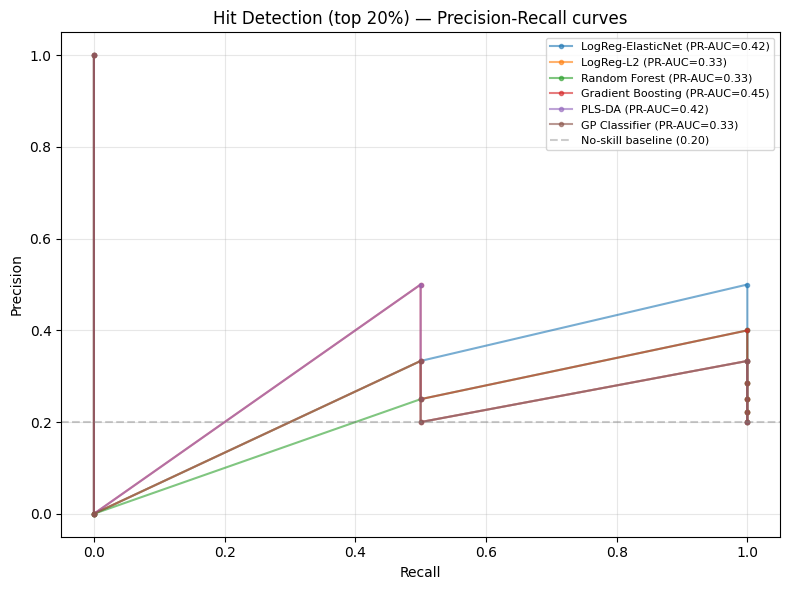

In [8]:
# Plot PR curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in hit_probas.items():
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, marker='.', alpha=0.6, label=f'{name} (PR-AUC={ap:.2f})')
ax.axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.4,
           label=f'No-skill baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Hit Detection (top 20%) — Precision-Recall curves')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# "Flop" avoidance


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, is_flop, test_size=0.2, random_state=42, stratify=is_flop)
print(f'Flop avoidance: train {len(X_train)} ({y_train.value_counts().to_dict()}), '
      f'test {len(X_test)} ({y_test.value_counts().to_dict()})')

baseline = 1 - y_test.mean()
print(f'Majority-class baseline accuracy: {baseline:.2%}')
print()

flop_results = {}
flop_probas  = {}
for name, factory in CLASSIFIERS.items():
    pipe = factory()
    metrics, proba = evaluate_binary(pipe, X_train, y_train, X_test, y_test)
    flop_results[name] = metrics
    flop_probas[name]  = proba
    print(f'  {name:22s}  AUC={metrics["roc_auc"]:.2f}  PR-AUC={metrics["pr_auc"]:.2f}  '
          f'F1={metrics["f1"]:.2f}  P@R80={metrics["precision_at_recall80"]:.2f}')

best_flop = max(flop_results, key=lambda k: flop_results[k]['pr_auc']
                 if not np.isnan(flop_results[k]['pr_auc']) else -1)
print(f'\nBest flop screener (by PR-AUC): {best_flop}')
display(pd.DataFrame(flop_results).T.sort_values('pr_auc', ascending=False).round(3))

Flop avoidance: train 40 ({0: 28, 1: 12}), test 10 ({0: 7, 1: 3})
Majority-class baseline accuracy: 70.00%

  LogReg-ElasticNet       AUC=0.81  PR-AUC=0.59  F1=0.67  P@R80=0.60
  LogReg-L2               AUC=0.81  PR-AUC=0.59  F1=0.67  P@R80=0.60
  Random Forest           AUC=0.76  PR-AUC=0.53  F1=0.40  P@R80=0.60
  Gradient Boosting       AUC=0.81  PR-AUC=0.70  F1=0.57  P@R80=0.60
  PLS-DA                  AUC=0.81  PR-AUC=0.59  F1=0.40  P@R80=0.60
  GP Classifier           AUC=0.81  PR-AUC=0.59  F1=0.40  P@R80=0.60

Best flop screener (by PR-AUC): Gradient Boosting


,accuracy,f1,precision,recall,roc_auc,pr_auc,precision_at_recall80,threshold_at_recall80
Gradient Boosting,0.7,0.571,0.500,0.667,0.810,0.700,0.6,0.280
LogReg-ElasticNet,0.8,0.667,0.667,0.667,0.810,0.589,0.6,0.495
LogReg-L2,0.8,0.667,0.667,0.667,0.810,0.589,0.6,0.290
GP Classifier,0.7,0.400,0.500,0.333,0.810,0.589,0.6,0.378
PLS-DA,0.7,0.400,0.500,0.333,0.810,0.589,0.6,0.272
Random Forest,0.7,0.400,0.500,0.333,0.762,0.533,0.6,0.314


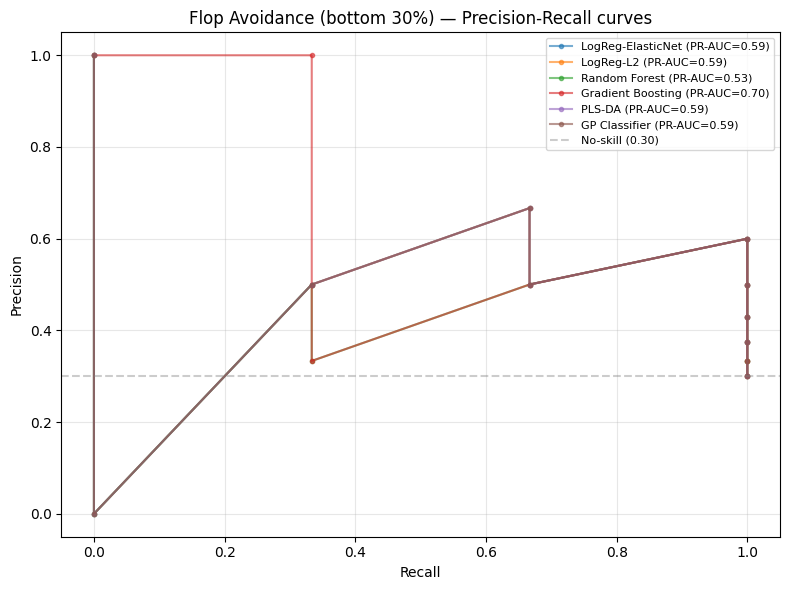

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in flop_probas.items():
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, marker='.', alpha=0.6, label=f'{name} (PR-AUC={ap:.2f})')
ax.axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.4,
           label=f'No-skill ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Flop Avoidance (bottom 30%) — Precision-Recall curves')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Simulated to real transfer per classification framing


In [11]:
X_syn = X_all[synth_mask].reset_index(drop=True)
X_real_test = X_all[~synth_mask].reset_index(drop=True)
y_syn_hit = is_hit[synth_mask].reset_index(drop=True)
y_real_hit = is_hit[~synth_mask].reset_index(drop=True)
y_syn_flop = is_flop[synth_mask].reset_index(drop=True)
y_real_flop = is_flop[~synth_mask].reset_index(drop=True)

print(f'Synthetic train: {len(X_syn)} (hit fraction {y_syn_hit.mean():.0%}, '
      f'flop fraction {y_syn_flop.mean():.0%})')
print(f'Real test:       {len(X_real_test)} (hit fraction {y_real_hit.mean():.0%}, '
      f'flop fraction {y_real_flop.mean():.0%})')

transfer_results = {}
for name, factory in CLASSIFIERS.items():
    transfer_results[name] = {}
    for task_name, y_tr, y_te in [
        ('hit',  y_syn_hit,  y_real_hit),
        ('flop', y_syn_flop, y_real_flop),
    ]:
        pipe = factory()
        metrics, _ = evaluate_binary(pipe, X_syn, y_tr, X_real_test, y_te)
        transfer_results[name][task_name] = metrics

print('\nSynth→real transfer (test n=10):')
print(f'\n  {"Model":<20s}  {"Hit AUC":>10s}  {"Hit P@R80":>10s}  '
      f'{"Flop AUC":>10s}  {"Flop P@R80":>10s}')
for name, tr in transfer_results.items():
    h = tr['hit']; f = tr['flop']
    p_h_80 = '   nan' if np.isnan(h["precision_at_recall80"]) else f'{h["precision_at_recall80"]:>10.2f}'
    p_f_80 = '   nan' if np.isnan(f["precision_at_recall80"]) else f'{f["precision_at_recall80"]:>10.2f}'
    print(f'  {name:<20s}  {h["roc_auc"]:>10.2f}  {p_h_80}  '
          f'{f["roc_auc"]:>10.2f}  {p_f_80}')

Synthetic train: 40 (hit fraction 18%, flop fraction 30%)
Real test:       10 (hit fraction 30%, flop fraction 30%)

Synth→real transfer (test n=10):

  Model                    Hit AUC   Hit P@R80    Flop AUC  Flop P@R80
  LogReg-ElasticNet           0.67        0.38        0.71        0.50
  LogReg-L2                   0.76        0.50        0.67        0.50
  Random Forest               0.81        0.60        0.71        0.50
  Gradient Boosting           1.00        1.00        0.57        0.50
  PLS-DA                      0.62        0.43        0.67        0.50
  GP Classifier               0.76        0.50        0.76        0.60


In [13]:
out = {
    'task': 'business_classification_hit_flop',
    'thresholds': {'hit_quantile': 0.80, 'flop_quantile': 0.30,
                   'hit_threshold': float(hit_threshold),
                   'flop_threshold': float(flop_threshold)},
    'class_distributions': {
        'is_hit':  {str(k): int(v) for k, v in is_hit.value_counts().items()},
        'is_flop': {str(k): int(v) for k, v in is_flop.value_counts().items()},
        'tier':    tier.value_counts().to_dict(),
    },
    'feature_count': len(feature_cols),
    'hit_detection':   hit_results,
    'flop_avoidance':  flop_results,
    'synth_to_real_transfer': transfer_results,
}
out_path = RUN_DIR / 'results_business_classification.json'
with open(out_path, 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved → {out_path}')

Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3/results_business_classification.json
